# KAIST Urban16 LiDAR Scan-to-Map Localization

Diagnostic notebook for registering raw KAIST Left VLP scans against the supplied Urban16 reconstructed LAS map. The reference/global trajectory is used only as an initialization and local-crop aid; each scan is localized independently with scan-to-map ICP, and accepted outputs are absolute `T_W_L` poses in the LAS/map/world frame.

In [11]:
from pathlib import Path
import numpy as np

# Editable dataset paths. These match notebook 18's Urban16 convention for raw Left VLP scans.
DATASET_ROOT = Path('/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16')
LAS_MAP_ROOT = DATASET_ROOT / 'urban16_las'
RAW_LIDAR_ROOT = DATASET_ROOT / 'urban16_data/urban16/sensor_data/VLP_left'
REFERENCE_POSE_PATH = DATASET_ROOT / 'urban16_pose/urban16/global_pose.csv'
OUTPUT_CSV_PATH = Path('~/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv').expanduser()

# KAIST Left VLP extrinsic from notebook 19. T_B_LL maps Left LiDAR coordinates into vehicle/body coordinates.
T_B_LL = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [0.486485, -0.711672, 0.506809, 0.397052],
    [-0.706447, 0.0208933, 0.707457, 1.90953],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)

MAP_VOXEL_SIZE_M = 0.25
SCAN_VOXEL_SIZE_M = 0.25
MAP_CROP_RADIUS_M = 50.0
MAP_CROP_Z_MARGIN_M = 10.0
MAX_CORRESPONDENCE_DISTANCE_M = 1.5
MAX_ITERATIONS = 50
VOXEL_SCALE_FACTORS = (2.0, 1.0, 0.5)
ROBUST_KERNEL = 'tukey'
DEVICE = 'cuda'
CUDA_DEVICE_ID = 0
MAX_SCANS = None
SCAN_STEP = 1
SAVE_CSV = True

INITIAL_GUESS_SOURCE = 'reference'
MAX_REFERENCE_MISMATCH_S = 5
SHORT_TEST_SCANS = 200
RUN_FULL_LOCALIZATION = True
EXTRACT_RAW_LIDAR_IF_NEEDED = False
PLOT_MAP_POINTS = 200_000
MAP_CHUNK_SIZE_POINTS = 5_000_000
MAP_LOAD_MODE = 'selected_scans'  # 'selected_scans' or 'full'
MAP_LOAD_XY_MARGIN_M = MAP_CROP_RADIUS_M + 10.0
MAP_LOAD_Z_MARGIN_M = MAP_CROP_Z_MARGIN_M + 5.0

##################################################
# Optimized scan-to-map processing
##################################################

# CPU mode:
# None automatically chooses a reasonable number of physical cores, capped at 8.
CPU_WORKERS = None
CPU_THREADS_PER_WORKER = 1

# Spatial cache of already prepared LAS target crops.
MAP_CACHE_CELL_SIZE_M = 10.0
MAP_CACHE_SIZE = 4

# CUDA mode:
# Raw scans are loaded ahead of the GPU by CPU threads.
CUDA_PREFETCH_WORKERS = 2
CUDA_PREFETCH_DEPTH = 8

# Do not force garbage collection after every scan.
# Change to ~2000 only if memory actually grows during a long run.
CLEANUP_INTERVAL_SCANS = 0

In [2]:
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').is_dir() and (REPO_ROOT.parent / 'src').is_dir():
    REPO_ROOT = REPO_ROOT.parent
SRC_PATH = REPO_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from kaist_dataset.data import import_true_trajectory
from kaist_dataset.lidar import discover_lidar_archives, discover_lidar_scans, scan_timestamps_from_paths, sort_by_filename
from kaist_dataset.lidar_map import (
    LidarMapRegistrationResult,
    LidarReferenceMap,
    bounds_around_positions,
    choose_open3d_device,
    compose_initial_lidar_pose,
    discover_las_files,
    initial_lidar_positions_from_reference,
    load_lidar_map_pose_csv,
    localize_lidar_scans_to_map,
    plot_localization_trajectories,
    plot_reference_map_overview,
    plot_registration_diagnostics,
    plot_registration_result_projections,
    registration_results_to_dataframe,
    save_lidar_map_pose_csv,
    select_scans_overlapping_reference,
)

plt.rcParams['figure.dpi'] = 120
print(f'Repository root: {REPO_ROOT}')

Repository root: /home/camel/Skoltech/phd_proposal


In [3]:
raw_archives = discover_lidar_archives(RAW_LIDAR_ROOT)
raw_scans = discover_lidar_scans(RAW_LIDAR_ROOT, extract_if_needed=EXTRACT_RAW_LIDAR_IF_NEEDED)
raw_scans = sort_by_filename(raw_scans)
scan_timestamps_s = scan_timestamps_from_paths(raw_scans)
las_files = discover_las_files(LAS_MAP_ROOT)
reference_timestamps_s, reference_poses_T_W_B = import_true_trajectory(REFERENCE_POSE_PATH)
effective_device = choose_open3d_device(DEVICE, CUDA_DEVICE_ID)

print(f'Raw Left VLP scan root: {RAW_LIDAR_ROOT}')
print(f'Raw archives found: {len(raw_archives)}')
print(f'Raw scans found: {len(raw_scans)}')
print(f'LAS files found: {len(las_files)}')
print(f'Reference poses: {len(reference_timestamps_s)}')
print(f'Requested device: {DEVICE}, effective device: {effective_device}, CUDA_DEVICE_ID={CUDA_DEVICE_ID}')
if raw_scans:
    print(f'First/last LiDAR timestamps: {scan_timestamps_s[0]:.9f} .. {scan_timestamps_s[-1]:.9f}')
print(f'First/last reference timestamps: {reference_timestamps_s[0]:.9f} .. {reference_timestamps_s[-1]:.9f}')
print('First LAS files:')
for path in las_files[:5]:
    print(f'  {path}')

Raw Left VLP scan root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data/VLP_left
Raw archives found: 0
Raw scans found: 44535
LAS files found: 1
Reference poses: 308734
Requested device: cpu, effective device: cpu, CUDA_DEVICE_ID=0
First/last LiDAR timestamps: 1524205093.025644064 .. 1524209584.807601929
First/last reference timestamps: 1524205131.600492239 .. 1524209584.840519905
First LAS files:
  /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_las/urban16/sick_pointcloud.las


In [4]:
short_scan_paths, short_scan_timestamps_s = select_scans_overlapping_reference(
    raw_scans,
    scan_timestamps_s,
    reference_timestamps_s,
    max_scans=SHORT_TEST_SCANS,
    scan_step=SCAN_STEP,
    margin_s=0.0,
    max_reference_mismatch_s=MAX_REFERENCE_MISMATCH_S,
)
if len(short_scan_paths) < 20:
    warnings.warn('Fewer than 20 scans overlap the reference trajectory with the current path/timestamp settings.', RuntimeWarning)

if RUN_FULL_LOCALIZATION:
    map_scan_paths, map_scan_timestamps_s = select_scans_overlapping_reference(
        raw_scans,
        scan_timestamps_s,
        reference_timestamps_s,
        max_scans=MAX_SCANS,
        scan_step=SCAN_STEP,
        margin_s=0.0,
        max_reference_mismatch_s=MAX_REFERENCE_MISMATCH_S,
    )
else:
    map_scan_paths, map_scan_timestamps_s = short_scan_paths, short_scan_timestamps_s

if not map_scan_paths:
    raise RuntimeError('No raw Left VLP scans overlap the reference trajectory with the current configuration.')

map_bounds_min = None
map_bounds_max = None
if MAP_LOAD_MODE == 'selected_scans':
    map_initial_positions_W, map_reference_mismatches_s = initial_lidar_positions_from_reference(
        map_scan_timestamps_s,
        reference_timestamps_s,
        reference_poses_T_W_B,
        T_B_LL,
        max_reference_mismatch_s=MAX_REFERENCE_MISMATCH_S,
    )
    map_bounds_min, map_bounds_max = bounds_around_positions(
        map_initial_positions_W,
        xy_margin_m=MAP_LOAD_XY_MARGIN_M,
        z_margin_m=MAP_LOAD_Z_MARGIN_M,
    )
    print(f'Map load mode: selected_scans; loading LAS points inside bounds:')
    print(f'  min XYZ: {map_bounds_min}')
    print(f'  max XYZ: {map_bounds_max}')
elif MAP_LOAD_MODE == 'full':
    print('Map load mode: full; loading all discovered LAS points before downsampling.')
else:
    raise ValueError("MAP_LOAD_MODE must be 'selected_scans' or 'full'.")

reference_map = LidarReferenceMap.from_las_files(
    las_files,
    voxel_size_m=MAP_VOXEL_SIZE_M,
    bounds_min_xyz=map_bounds_min,
    bounds_max_xyz=map_bounds_max,
    chunk_size_points=MAP_CHUNK_SIZE_POINTS,
    progress=True,
)
map_min, map_max = reference_map.bounds

print(f'Map points before bounds/downsampling: {reference_map.original_point_count:,}')
print(f'Map points after downsampling/indexing:  {reference_map.point_count:,}')
print(f'Map voxel size: {MAP_VOXEL_SIZE_M} m')
print(f'Map bounds min XYZ: {map_min}')
print(f'Map bounds max XYZ: {map_max}')

Map load mode: selected_scans; loading LAS points inside bounds:
  min XYZ: [ 3.15394696e+05  4.15418319e+06 -3.92465022e+00]
  max XYZ: [3.18093253e+05 4.15618309e+06 3.83424826e+01]


Loading sick_pointcloud.las: 27chunk [04:36, 10.24s/chunk]


Map points before bounds/downsampling: 130,948,672
Map points after downsampling/indexing:  18,618,707
Map voxel size: 0.25 m
Map bounds min XYZ: [3.15421248e+05 4.15418496e+06 8.86279842e+00]
Map bounds max XYZ: [3.18091318e+05 4.15617983e+06 3.83327984e+01]


# benchmarking

In [10]:
from time import perf_counter


def benchmark_map_localization(device, **kwargs):
    start = perf_counter()

    results = localize_lidar_scans_to_map(
        reference_map,
        short_scan_paths,
        reference_timestamps_s,
        reference_poses_T_W_B,
        T_B_LL,
        max_scans=1000,
        device=device,
        progress=True,
        **kwargs,
    )

    elapsed = perf_counter() - start
    successful = sum(result.success for result in results)

    print()
    print('device:', device)
    print('elapsed [s]:', elapsed)
    print('ms / scan:', elapsed / len(results) * 1000.0)
    print('scans / s:', len(results) / elapsed)
    print('successful:', successful, '/', len(results))

    return results

cuda_results = benchmark_map_localization(
    'cuda',
    cuda_device_id=0,
    map_cache_cell_size_m=15.0,
    map_cache_size=21,
    cuda_prefetch_workers=8,
    cuda_prefetch_depth=64,
)

LAS scan-to-map ICP [cuda]: 100%|██████████| 200/200 [00:33<00:00,  5.95it/s]


device: cuda
elapsed [s]: 33.657976536000206
ms / scan: 168.28988268000103
scans / s: 5.942127857451032
successful: 200 / 200


In [6]:


cpu_results = benchmark_map_localization(
    'cpu',
    cpu_workers=24,
    cpu_threads_per_worker=1,
    map_cache_cell_size_m=10.0,
    map_cache_size=4,
)

LAS scan-to-map ICP [cpu x24]: 100%|██████████| 200/200 [01:57<00:00,  1.70it/s]



device: cpu
elapsed [s]: 118.72905252300188
ms / scan: 593.6452626150094
scans / s: 1.6845076731430426
successful: 200 / 200


## Visual Sanity Check

The LAS map and reference vehicle trajectory should occupy the same global/map frame before any scan registration is attempted.

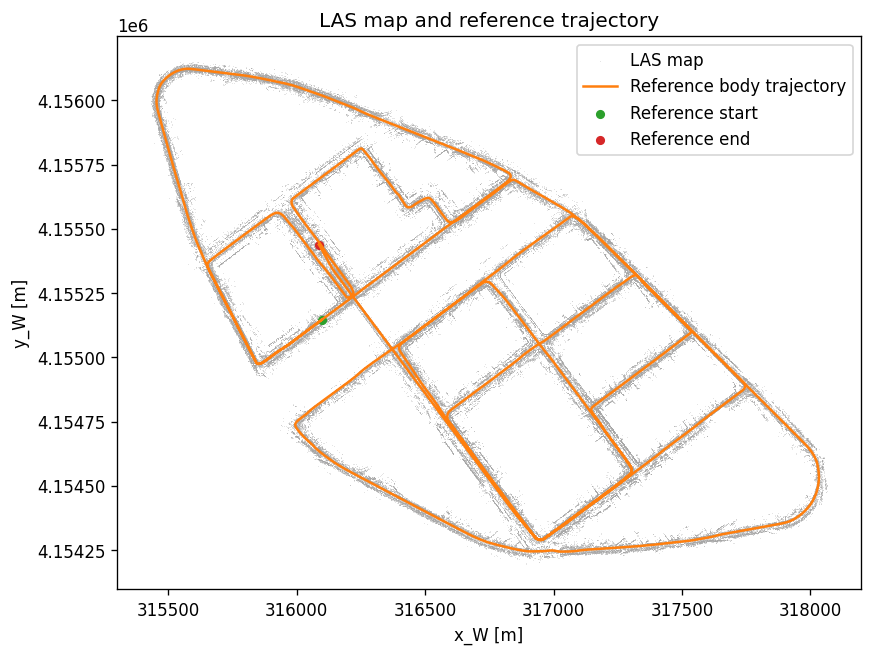

In [12]:
ax = plot_reference_map_overview(reference_map, reference_poses_T_W_B=reference_poses_T_W_B, max_map_points=PLOT_MAP_POINTS)
plt.show()

In [13]:
print(f'Short-test scans selected: {len(short_scan_paths)}')
if short_scan_paths:
    print(f'Short-test timestamp range: {short_scan_timestamps_s[0]:.9f} .. {short_scan_timestamps_s[-1]:.9f}')
print(f'Map was built for {len(map_scan_paths)} selected scan timestamp(s).')

Short-test scans selected: 200
Short-test timestamp range: 1524205131.660108089 .. 1524205151.730709076
Map was built for 37654 selected scan timestamp(s).


In [18]:
short_results = localize_lidar_scans_to_map(
    reference_map,
    short_scan_paths,
    reference_timestamps_s,
    reference_poses_T_W_B,
    T_B_LL,
    initial_guess_source=INITIAL_GUESS_SOURCE,
    max_reference_mismatch_s=MAX_REFERENCE_MISMATCH_S,
    scan_voxel_size_m=SCAN_VOXEL_SIZE_M,
    map_crop_radius_m=MAP_CROP_RADIUS_M,
    map_crop_z_margin_m=MAP_CROP_Z_MARGIN_M,
    max_correspondence_distance_m=MAX_CORRESPONDENCE_DISTANCE_M,
    max_iterations=MAX_ITERATIONS,
    voxel_scale_factors=VOXEL_SCALE_FACTORS,
    robust_kernel=ROBUST_KERNEL,
    device=effective_device,
    cuda_device_id=CUDA_DEVICE_ID,
    progress=True,
)

short_diagnostics = registration_results_to_dataframe(short_results)
print(f'Short-test successes: {int(short_diagnostics.success.sum())} / {len(short_diagnostics)}')
short_diagnostics

LAS scan-to-map ICP [cuda]:   0%|          | 0/200 [00:00<?, ?it/s]

LAS scan-to-map ICP [cuda]: 100%|██████████| 200/200 [00:35<00:00,  5.67it/s]


Short-test successes: 200 / 200


,timestamp_s,scan_path,success,fitness,inlier_rmse,reference_timestamp_mismatch_s,translation_correction_m,rotation_correction_deg,scan_points_used,map_points_used,message,initial_x,initial_y,initial_z,estimated_x,estimated_y,estimated_z
0,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.826991,0.226310,0.001614,0.289229,1.376935,10196,149341,,316098.315230,4.155145e+06,18.007244,316098.465181,4.155146e+06,17.837242
1,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.837972,0.219453,0.002775,0.309695,1.343978,10455,149341,,316097.976822,4.155145e+06,17.998668,316098.168436,4.155145e+06,17.852904
2,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.830715,0.219454,0.003886,0.238871,1.282973,10568,149341,,316097.631838,4.155145e+06,17.988128,316097.774854,4.155145e+06,17.864200
3,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.826302,0.232440,0.004840,0.120540,1.282297,10501,149341,,316097.282970,4.155145e+06,17.977408,316097.313590,4.155145e+06,17.870033
4,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.820340,0.225026,0.003980,0.157318,1.174879,10403,149341,,316096.922225,4.155144e+06,17.967919,316097.010409,4.155144e+06,17.866743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.771490,0.191875,0.000262,0.514595,0.819735,8341,147638,,315957.253668,4.155041e+06,19.360222,315957.686862,4.155041e+06,19.312998
196,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.766190,0.191226,0.001351,0.514448,0.851975,8323,147638,,315956.551891,4.155041e+06,19.374257,315956.983651,4.155041e+06,19.322941
197,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.762704,0.188763,0.002594,0.501341,0.870053,8285,147638,,315955.844846,4.155040e+06,19.390958,315956.266182,4.155041e+06,19.337444
198,1.524205e+09,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban1...,True,0.757858,0.194163,0.003681,0.556343,0.897770,8367,147070,,315955.124809,4.155040e+06,19.407929,315955.593409,4.155040e+06,19.354083


In [19]:
diagnostic_columns = [
    'timestamp_s', 'success', 'fitness', 'inlier_rmse', 'reference_timestamp_mismatch_s',
    'translation_correction_m', 'rotation_correction_deg', 'scan_points_used', 'map_points_used', 'message',
]
short_diagnostics.loc[:, diagnostic_columns]

,timestamp_s,success,fitness,inlier_rmse,reference_timestamp_mismatch_s,translation_correction_m,rotation_correction_deg,scan_points_used,map_points_used,message
0,1.524205e+09,True,0.826991,0.226310,0.001614,0.289229,1.376935,10196,149341,
1,1.524205e+09,True,0.837972,0.219453,0.002775,0.309695,1.343978,10455,149341,
2,1.524205e+09,True,0.830715,0.219454,0.003886,0.238871,1.282973,10568,149341,
3,1.524205e+09,True,0.826302,0.232440,0.004840,0.120540,1.282297,10501,149341,
4,1.524205e+09,True,0.820340,0.225026,0.003980,0.157318,1.174879,10403,149341,
...,...,...,...,...,...,...,...,...,...,...
195,1.524205e+09,True,0.771490,0.191875,0.000262,0.514595,0.819735,8341,147638,
196,1.524205e+09,True,0.766190,0.191226,0.001351,0.514448,0.851975,8323,147638,
197,1.524205e+09,True,0.762704,0.188763,0.002594,0.501341,0.870053,8285,147638,
198,1.524205e+09,True,0.757858,0.194163,0.003681,0.556343,0.897770,8367,147070,


## Registered Scan Overlays

Each panel overlays the transformed raw Left VLP scan on the local LAS crop. The scan is transformed by the estimated absolute `T_W_L`; the LAS crop remains in world/map coordinates.

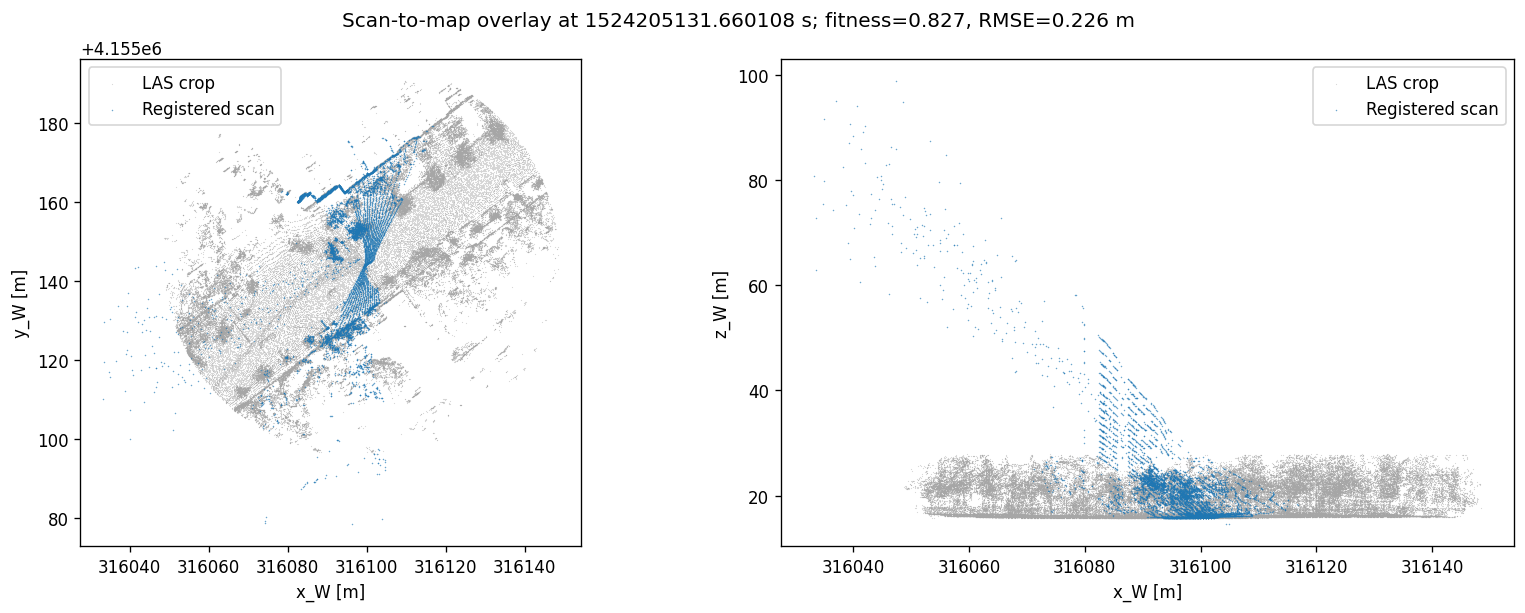

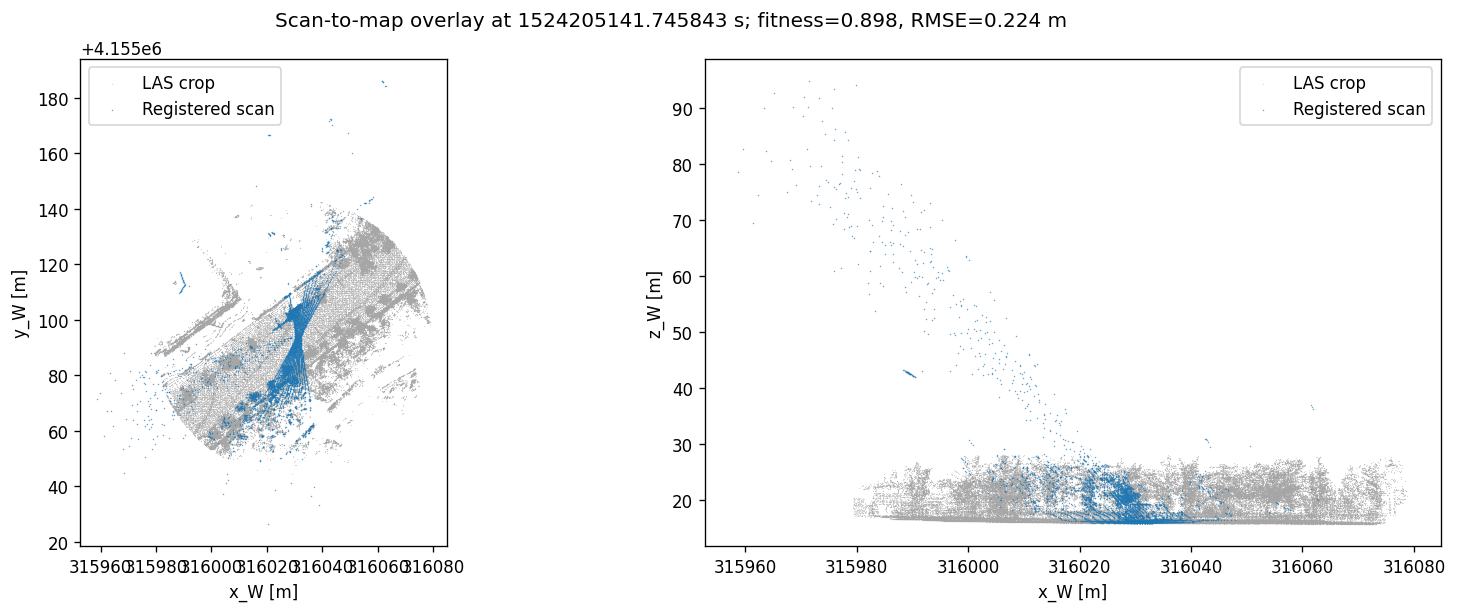

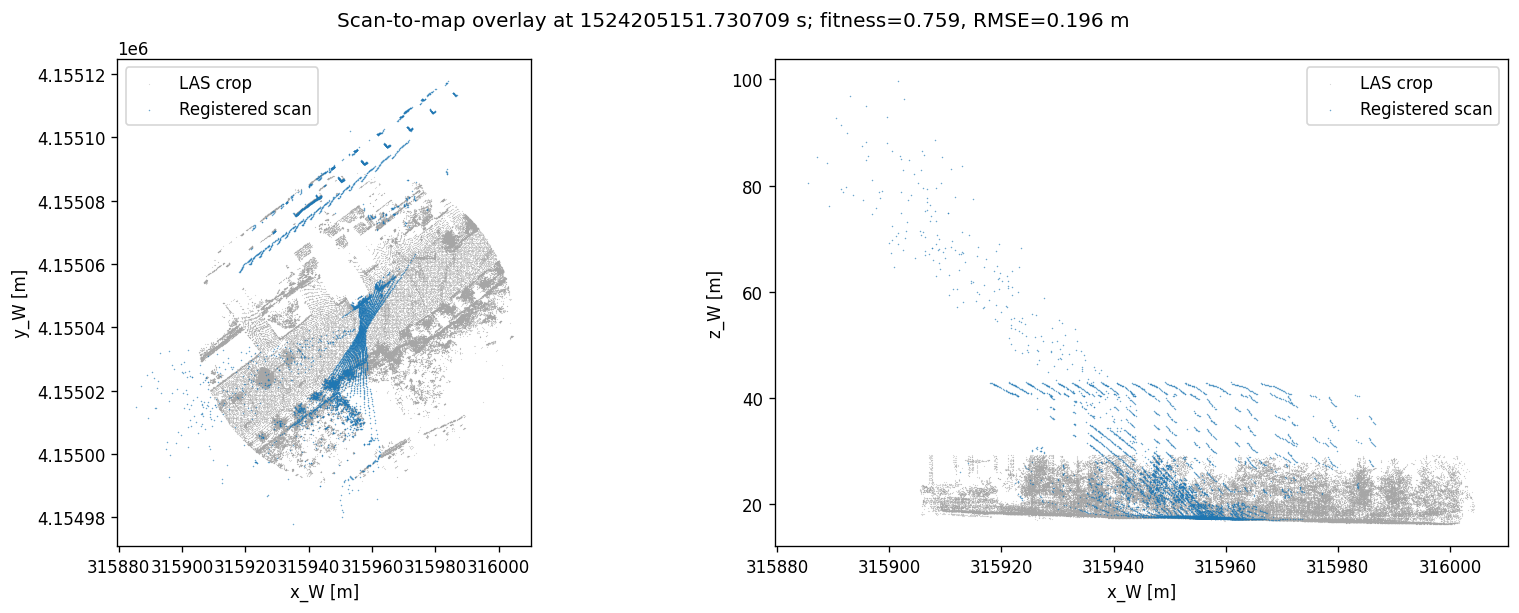

In [20]:
successful_results = [result for result in short_results if result.success and result.T_W_L_estimated is not None]
if not successful_results:
    warnings.warn('No successful short-test registrations to plot.', RuntimeWarning)
else:
    plot_indices = sorted(set([0, len(successful_results) // 2, len(successful_results) - 1]))
    for index in plot_indices:
        fig, axes = plot_registration_result_projections(
            reference_map,
            successful_results[index],
            crop_radius_m=MAP_CROP_RADIUS_M,
            crop_z_margin_m=MAP_CROP_Z_MARGIN_M,
            scan_voxel_size_m=SCAN_VOXEL_SIZE_M,
        )
        plt.show()

## Trajectory and Corrections

The initial LiDAR trajectory is `T_W_L_initial = T_W_B_initial @ T_B_LL`, where `T_B_LL` maps Left LiDAR points into the vehicle/body frame. ICP estimates are independent absolute scan-to-map `T_W_L` poses.

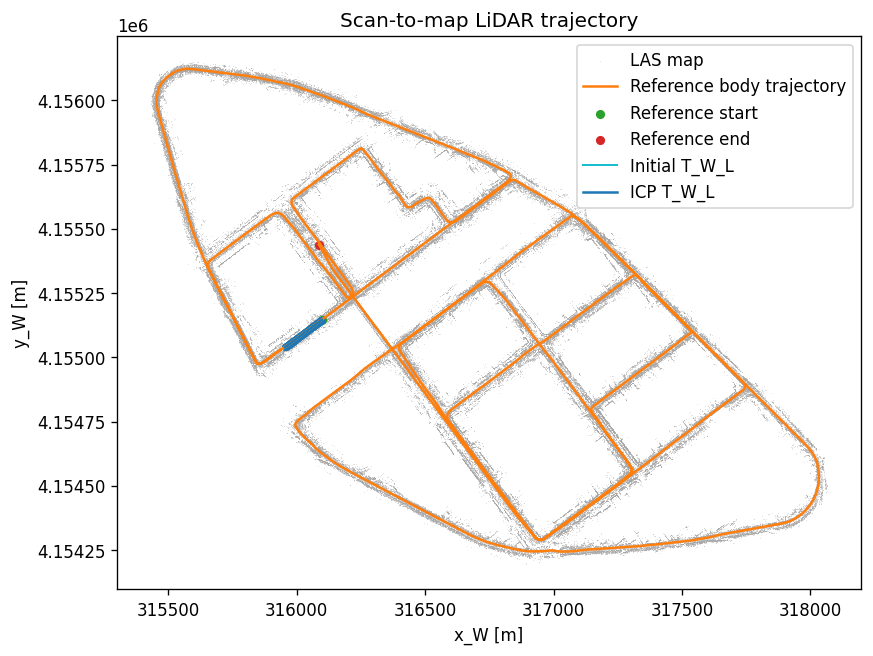

In [21]:
ax = plot_localization_trajectories(reference_map, short_results, reference_poses_T_W_B=reference_poses_T_W_B, max_map_points=PLOT_MAP_POINTS)
plt.show()

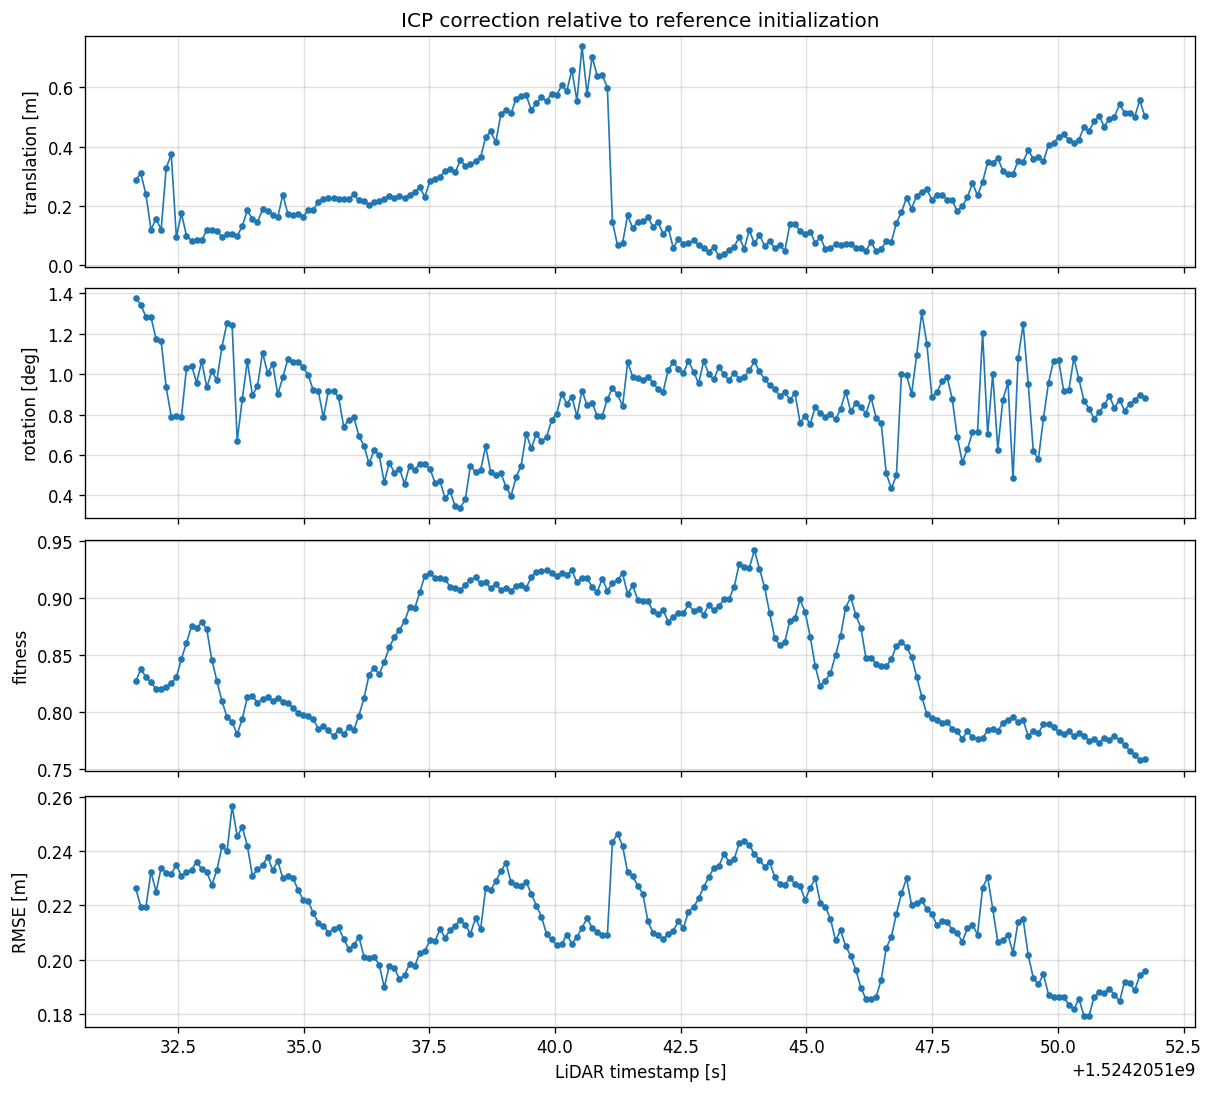

In [22]:
fig, axes = plot_registration_diagnostics(short_results)
plt.show()

In [23]:
short_csv_path = OUTPUT_CSV_PATH.with_name(f'{OUTPUT_CSV_PATH.stem}_short_test{OUTPUT_CSV_PATH.suffix}')
if SAVE_CSV and short_results:
    saved_short_csv = save_lidar_map_pose_csv(short_results, short_csv_path)
    print(f'Saved short-test CSV: {saved_short_csv}')
else:
    saved_short_csv = None
    print('Short-test CSV saving skipped.')

Saved short-test CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left_short_test.csv


## Optional Full Localization Run

Leave `RUN_FULL_LOCALIZATION = False` while debugging. When enabled, this processes all overlapping scans subject to `MAX_SCANS` and `SCAN_STEP`, then saves the requested CSV.

In [24]:
full_results = None
if RUN_FULL_LOCALIZATION:
    full_scan_paths, full_scan_timestamps_s = select_scans_overlapping_reference(
        raw_scans,
        scan_timestamps_s,
        reference_timestamps_s,
        max_scans=MAX_SCANS,
        scan_step=SCAN_STEP,
        margin_s=MAX_REFERENCE_MISMATCH_S,
    )
    print(f'Full-run scans selected: {len(full_scan_paths)}')
    full_results = localize_lidar_scans_to_map(
        reference_map,
        full_scan_paths,
        reference_timestamps_s,
        reference_poses_T_W_B,
        T_B_LL,
        initial_guess_source=INITIAL_GUESS_SOURCE,
        max_reference_mismatch_s=MAX_REFERENCE_MISMATCH_S,
        scan_voxel_size_m=SCAN_VOXEL_SIZE_M,
        map_crop_radius_m=MAP_CROP_RADIUS_M,
        map_crop_z_margin_m=MAP_CROP_Z_MARGIN_M,
        max_correspondence_distance_m=MAX_CORRESPONDENCE_DISTANCE_M,
        max_iterations=MAX_ITERATIONS,
        voxel_scale_factors=VOXEL_SCALE_FACTORS,
        robust_kernel=ROBUST_KERNEL,
        device=effective_device,
        cuda_device_id=CUDA_DEVICE_ID,
        progress=True,
    )
    full_diagnostics = registration_results_to_dataframe(full_results)
    print(f'Full-run successes: {int(full_diagnostics.success.sum())} / {len(full_diagnostics)}')
    if SAVE_CSV:
        saved_full_csv = save_lidar_map_pose_csv(full_results, OUTPUT_CSV_PATH)
        print(f'Saved full localization CSV: {saved_full_csv}')
else:
    saved_full_csv = None
    print('Full localization skipped. Set RUN_FULL_LOCALIZATION = True to export all selected scans.')

Full-run scans selected: 44202


LAS scan-to-map ICP [cuda]: 100%|██████████| 44202/44202 [3:21:40<00:00,  3.65it/s]       


Full-run successes: 37704 / 44202
Saved full localization CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv


## CSV Reload Verification

The loader below reconstructs `T_W_L` matrices from the first 13 columns and plots the serialized estimated trajectory. Failed rows retain timestamps and diagnostics but contain NaN pose entries.

Loaded 44202 rows from /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv
['timestamp', 'r11', 'r12', 'r13', 't11', 'r21', 'r22', 'r23', 't21', 'r31', 'r32', 'r33', 't31']


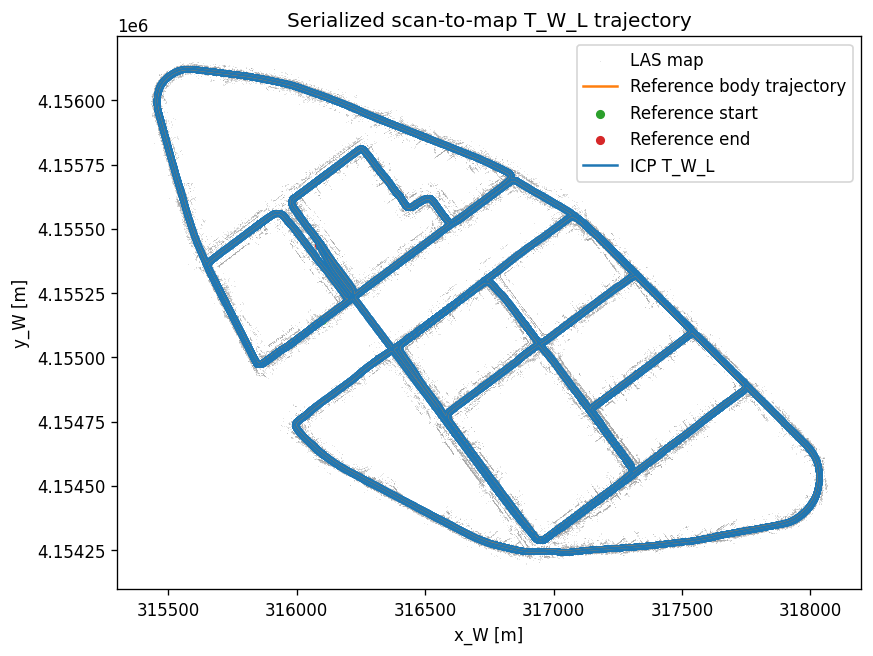

In [25]:
csv_path_to_verify = saved_full_csv if saved_full_csv is not None else saved_short_csv
if csv_path_to_verify is None:
    print('No CSV was saved in this notebook run.')
else:
    csv_timestamps_s, csv_poses_T_W_L, csv_dataframe = load_lidar_map_pose_csv(csv_path_to_verify)
    print(f'Loaded {len(csv_dataframe)} rows from {csv_path_to_verify}')
    print(list(csv_dataframe.columns[:13]))
    csv_results = []
    for row_index, row in csv_dataframe.iterrows():
        success = bool(row.get('success', True)) and np.all(np.isfinite(csv_poses_T_W_L[row_index, :3, :]))
        csv_results.append(LidarMapRegistrationResult(timestamp_s=float(csv_timestamps_s[row_index]), scan_path='', T_W_L_initial=None, T_W_L_estimated=csv_poses_T_W_L[row_index] if success else None, success=success, fitness=float(row.get('fitness', np.nan)), inlier_rmse=float(row.get('inlier_rmse', np.nan))))
    ax = plot_localization_trajectories(reference_map, csv_results, reference_poses_T_W_B=reference_poses_T_W_B, max_map_points=PLOT_MAP_POINTS)
    ax.set_title('Serialized scan-to-map T_W_L trajectory')
    plt.show()
    csv_dataframe.head()